In [ ]:
!pip -q install prophet pandas numpy scikit-learn matplotlib seaborn


# **Linear Trend**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
data_dir = "/content/BayesianFinalProjects"

train_path = f"{data_dir}/train_FD001.txt"
test_path  = f"{data_dir}/test_FD001.txt"
rul_path   = f"{data_dir}/RUL_FD001.txt"

col_names = (
    ["unit_id", "cycle"] +
    [f"op_setting_{i}" for i in range(1, 4)] +
    [f"s_{i}" for i in range(1, 22)]
)

train_df = pd.read_csv(train_path, sep=r"\s+", header=None)
test_df  = pd.read_csv(test_path,  sep=r"\s+", header=None)
rul_df   = pd.read_csv(rul_path,   sep=r"\s+", header=None)

train_df = train_df.iloc[:, :26]
test_df  = test_df.iloc[:, :26]

train_df.columns = col_names
test_df.columns = col_names
rul_df.columns = ["RUL_truth"]

print("train shape:", train_df.shape)
print("test shape :", test_df.shape)
print("truth shape:", rul_df.shape)
train_df.head()


train shape: (20631, 26)
test shape : (13096, 26)
truth shape: (100, 1)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
max_cycle = train_df.groupby("unit_id")["cycle"].max().reset_index()
max_cycle.columns = ["unit_id", "max_cycle"]

train_df = train_df.merge(max_cycle, on="unit_id", how="left")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df.drop(columns=["max_cycle"], inplace=True)

RUL_CAP = 125
train_df["RUL"] = train_df["RUL"].clip(upper=RUL_CAP)

train_df.loc[train_df['RUL'] < 125, ["unit_id", "cycle", "RUL"]]


,unit_id,cycle,RUL
67,1,68,124
68,1,69,123
69,1,70,122
70,1,71,121
71,1,72,120
...,...,...,...
20626,100,196,4
20627,100,197,3
20628,100,198,2
20629,100,199,1


In [4]:
sensor_cols = ["s_2","s_3","s_4","s_7","s_8","s_9","s_11","s_12","s_13","s_14","s_15","s_17","s_20","s_21"]
base_cols = ["cycle", "op_setting_1", "op_setting_2", "op_setting_3"]
feature_cols = base_cols + sensor_cols

scaler = StandardScaler()
train_scaled = train_df.copy()
test_scaled = test_df.copy()

train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_scaled[feature_cols] = scaler.transform(test_df[feature_cols])

print("num features:", len(feature_cols))
feature_cols


num features: 18


['cycle',
 'op_setting_1',
 'op_setting_2',
 'op_setting_3',
 's_2',
 's_3',
 's_4',
 's_7',
 's_8',
 's_9',
 's_11',
 's_12',
 's_13',
 's_14',
 's_15',
 's_17',
 's_20',
 's_21']

In [5]:
def build_prophet_df(df, start_time="2000-01-01", y_col=None):
    out = df.copy().reset_index(drop=True)
    out["ds"] = pd.to_datetime(start_time) + pd.to_timedelta(np.arange(len(out)), unit="h")
    if y_col is not None:
        out["y"] = out[y_col].values
    return out

prophet_train = build_prophet_df(train_scaled, y_col="RUL")
prophet_test  = build_prophet_df(test_scaled, start_time=(prophet_train["ds"].max() + pd.Timedelta(hours=1)).strftime("%Y-%m-%d %H:%M:%S"))

prophet_train[["ds","y"] + feature_cols[:5]].head()


,ds,y,cycle,op_setting_1,op_setting_2,op_setting_3,s_2
0,2000-01-01 00:00:00,125,-1.565170,-0.315980,-1.372953,0.0,-1.721725
1,2000-01-01 01:00:00,125,-1.550652,0.872722,-1.031720,0.0,-1.061780
2,2000-01-01 02:00:00,125,-1.536134,-1.961874,1.015677,0.0,-0.661813
3,2000-01-01 03:00:00,125,-1.521616,0.324090,-0.008022,0.0,-0.661813
4,2000-01-01 04:00:00,125,-1.507098,-0.864611,-0.690488,0.0,-0.621816


In [6]:
m = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

for c in feature_cols:
    m.add_regressor(c)

train_for_fit = prophet_train[["ds", "y"] + feature_cols].copy()

m.fit(train_for_fit)

print("Prophet model trained.")


Prophet model trained.


---
**Training**

In [ ]:
train_pred = m.predict(prophet_train[["ds"] + feature_cols])
train_pred["yhat_clipped"] = train_pred["yhat"].clip(lower=0, upper=RUL_CAP)

mae = mean_absolute_error(prophet_train["y"], train_pred["yhat_clipped"])
mse = mean_squared_error(prophet_train["y"], train_pred["yhat_clipped"])
rmse = mse**0.5

print(f"Train MAE : {mae:.4f}")
print(f"Train RMSE: {rmse:.4f}")


Train MAE : 14.0809
Train RMSE: 18.5541


---
**Testing**

In [ ]:
test_forecast = m.predict(prophet_test[["ds"] + feature_cols])
test_forecast["yhat_clipped"] = test_forecast["yhat"].clip(lower=0, upper=RUL_CAP)

test_out = test_scaled.copy().reset_index(drop=True)
test_out["pred_rul"] = test_forecast["yhat_clipped"].values

pred_last = test_out.groupby("unit_id", as_index=False).tail(1).copy()
pred_last = pred_last.sort_values("unit_id").reset_index(drop=True)

result = pd.DataFrame({
    "unit_id": pred_last["unit_id"].values,
    "pred_rul": pred_last["pred_rul"].values,
    "true_rul": rul_df["RUL_truth"].values
})

mae_test = mean_absolute_error(result["true_rul"], result["pred_rul"])
mse = mean_squared_error(result["true_rul"], result["pred_rul"])
rmse_test = mse**0.5


print(f"Test MAE : {mae_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
result.head(10)


Test MAE : 17.8452
Test RMSE: 22.6266


,unit_id,pred_rul,true_rul
0,1,125.000000,112
1,2,107.871064,98
2,3,74.487350,69
3,4,84.136736,82
4,5,92.174113,91
5,6,93.979751,93
6,7,92.249237,91
7,8,72.014882,95
8,9,99.698753,111
9,10,78.418269,96


---
**NASA Score**

In [ ]:
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = 0.0
    for di in d:
        if di < 0:
            score += np.exp(-di / 13.0) - 1
        else:
            score += np.exp(di / 10.0) - 1
    return score

score = nasa_score(result["true_rul"].values, result["pred_rul"].values)
print(f"NASA Score: {score:.4f}")


NASA Score: 1289.2331


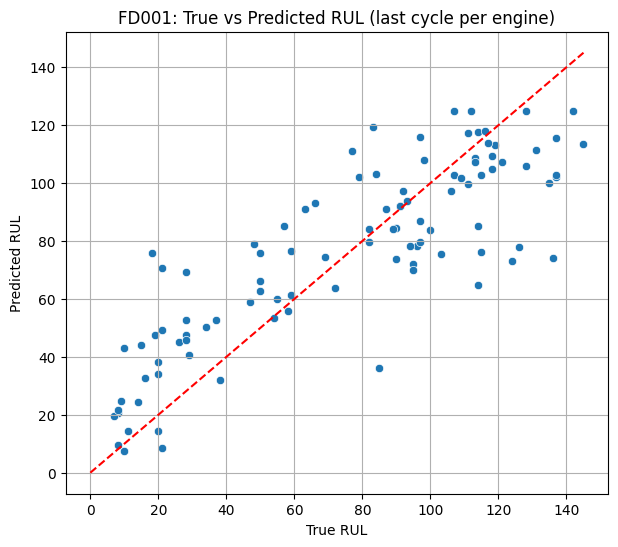

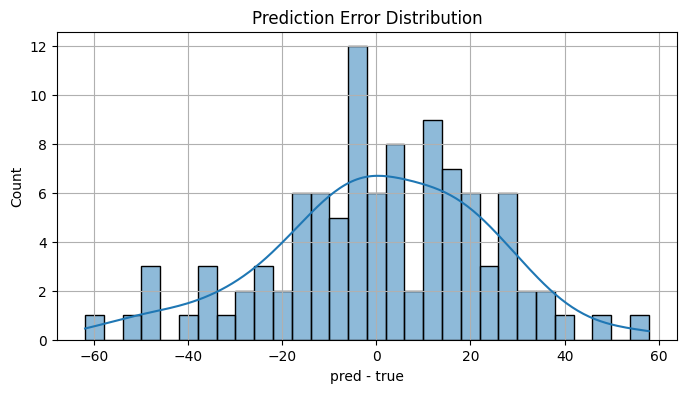

In [ ]:
plt.figure(figsize=(7,6))
sns.scatterplot(x="true_rul", y="pred_rul", data=result)
plt.plot([0, result["true_rul"].max()], [0, result["true_rul"].max()], "r--")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("FD001: True vs Predicted RUL (last cycle per engine)")
plt.grid(True)
plt.show()

result["error"] = result["pred_rul"] - result["true_rul"]
plt.figure(figsize=(8,4))
sns.histplot(result["error"], bins=30, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("pred - true")
plt.grid(True)
plt.show()


---
# **Non-Linear Trend**

In [7]:
m = Prophet(
    growth="logistic",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

for c in feature_cols:
    m.add_regressor(c)

train_for_fit = prophet_train[["ds", "y"] + feature_cols].copy()
train_for_fit['cap'] = RUL_CAP
m.fit(train_for_fit)

predict_df = prophet_train[["ds"] + feature_cols].copy()
predict_df['cap'] = RUL_CAP
predict_df['floor'] = 0

train_pred = m.predict(predict_df)
train_pred["yhat_clipped"] = train_pred["yhat"].clip(lower=0, upper=RUL_CAP)
print("Prophet model trained.")



Prophet model trained.


In [8]:
mae = mean_absolute_error(prophet_train["y"], train_pred["yhat_clipped"])
mse = mean_squared_error(prophet_train["y"], train_pred["yhat_clipped"])
rmse = mse**0.5

print(f"Train MAE : {mae:.4f}")
print(f"Train RMSE: {rmse:.4f}")


Train MAE : 14.5009
Train RMSE: 19.0406


In [9]:
prophet_test_input = prophet_test[["ds"] + feature_cols].copy()
prophet_test_input["cap"] = RUL_CAP
last_cycle_prediction = prophet_test_input.groupby("unit_id").tail(1)
test_forecast = m.predict(last_cycle_prediction,untertainty_samples=False)

test_forecast["yhat_clipped"] = test_forecast["yhat"].clip(lower=0, upper=RUL_CAP)

test_out = test_scaled.copy().reset_index(drop=True)
test_out["pred_rul"] = test_forecast["yhat_clipped"].values

pred_last = test_out.groupby("unit_id", as_index=False).tail(1).copy()
pred_last = pred_last.sort_values("unit_id").reset_index(drop=True)

result = pd.DataFrame({
    "unit_id": pred_last["unit_id"].values,
    "pred_rul": pred_last["pred_rul"].values,
    "true_rul": rul_df["RUL_truth"].values
})

mae_test = mean_absolute_error(result["true_rul"], result["pred_rul"])
mse = mean_squared_error(result["true_rul"], result["pred_rul"])
rmse_test = mse**0.5

print(f"Test MAE : {mae_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(result.head(10))


Test MAE : 17.9168
Test RMSE: 22.6941
   unit_id    pred_rul  true_rul
0        1  125.000000       112
1        2  107.207355        98
2        3   74.406083        69
3        4   83.912972        82
4        5   91.759450        91
5        6   93.585991        93
6        7   92.026894        91
7        8   71.632510        95
8        9   99.309911       111
9       10   78.345364        96


In [10]:
def nasa_score2(y_true, y_pred):
    d = y_pred - y_true
    score = 0.0
    for di in d:
        if di < 0:
            score += np.exp(-di / 13.0) - 1
        else:
            score += np.exp(di / 10.0) - 1
    return score

score = nasa_score2(result["true_rul"].values, result["pred_rul"].values)
print(f"NASA Score: {score:.4f}")


NASA Score: 1265.4672
